# Esercizio 3.3 - Inizializzazione Dataset Object Detection

Il notebook verifica l'integrità del `LitGTSRBDetectionDataModule`.
A differenza del task di classificazione, qui il target supervisionato include le coordinate spaziali delle bounding box (`x_min`, `y_min`, `x_max`, `y_max`) e l'ID di classe di ciascun segnale presente nella scena. I dati provengono dal dataset di detection `keremberke/german-traffic-sign-detection` (Hugging Face), che fornisce fotogrammi stradali completi con uno o piu' segnali per immagine, a differenza del dataset di classificazione GTSRB, dove ogni immagine e' gia' ritagliata attorno a un singolo segnale.

Obiettivo: Validazione visiva del parser tramite sovrapposizione del ground truth sulle immagini sorgente.

In [1]:
import sys
if '..' not in sys.path:
    sys.path.append('..')

from src.detection_data import LitGTSRBDetectionDataModule
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
# Inizializziamo il datamodule; il dataset viene scaricato automaticamente da Hugging Face
# e memorizzato in cache nella cartella indicata.
cache_dir = '../_data'
batch_size = 4
num_workers = 0  # 0 per evitare problemi di multiprocessing durante il debug interattivo su Windows

dm = LitGTSRBDetectionDataModule(cache_dir=cache_dir, batch_size=batch_size, num_workers=num_workers)
dm.setup()

# Otteniamo il DataLoader e leggiamo il primo batch per il sanity check.
train_loader = dm.train_dataloader()
images, targets = next(iter(train_loader))

print(f"Batch di {len(images)} immagini estratto con successo.")
print("Esempio del target della prima immagine:")
print(targets[0])

Batch di 4 immagini estratto con successo.
Esempio del target della prima immagine:
{'boxes': tensor([[949., 435., 979., 465.]]), 'labels': tensor([21]), 'image_id': tensor([256]), 'area': tensor([900.]), 'iscrowd': tensor([0])}


## Visualizzazione ground truth

Renderizzazione grafica delle coordinate della bounding box per confermare il corretto allineamento spaziale del parser prima dell'impiego nella Faster R-CNN.

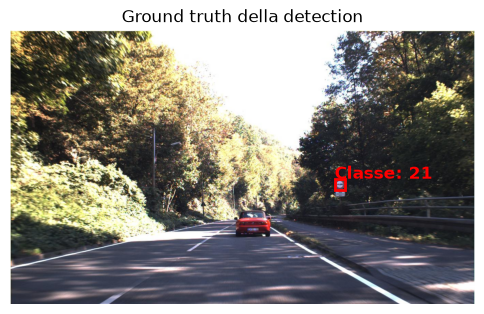

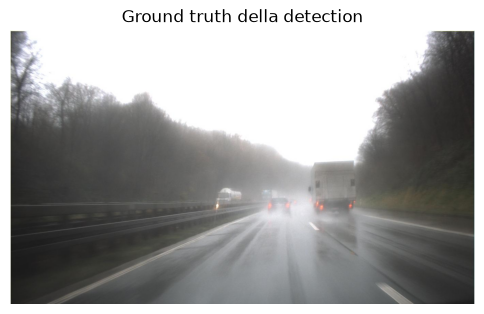

In [3]:
def plot_image_with_boxes(img_tensor, target):
    """Visualizza un'immagine con le bounding box annotate."""
    # Convertiamo l'immagine da tensor (C, H, W) a numpy array (H, W, C) per Matplotlib
    img_np = img_tensor.permute(1, 2, 0).numpy()
    
    fig, ax = plt.subplots(1, figsize=(6, 6))
    ax.imshow(img_np)
    
    # Estraiamo le box e creiamo le patch
    boxes = target['boxes'].numpy()
    labels = target['labels'].numpy()
    
    for box, label in zip(boxes, labels):
        xmin, ymin, xmax, ymax = box
        width = xmax - xmin
        height = ymax - ymin
        
        # Creiamo un rettangolo con Matplotlib
        rect = patches.Rectangle(
            (xmin, ymin), width, height,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
        
        # Etichetta della classe.
        ax.text(xmin, ymin - 2, f'Classe: {label}', color='red', fontsize=12, weight='bold')

    plt.axis('off')
    plt.title("Ground truth della detection")
    plt.show()

# Visualizziamo le prime 2 immagini del batch
for i in range(2):
    plot_image_with_boxes(images[i], targets[i])